# Phase 1: Dataset Analysis

This notebook performs the following analyses without altering the original images:
1. Exact duplicate detection (SHA-256)
2. Perceptual/near-duplicate detection (pHash)
3. Class distribution and imbalance analysis
4. Fixed stratified 70/15/15 train/validation/test split generation

In [1]:
import os
import hashlib
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import imagehash
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

# Constants
DATA_DIR = '../data_temp_pv/raw/color'
SPLIT_DIR = '../data/splits'

os.makedirs(SPLIT_DIR, exist_ok=True)

## 1. Exact Duplicate Analysis (SHA-256)
We use SHA-256 to compute a cryptographic hash for each image file. Files with identical hashes are exact duplicates (byte-for-byte).

In [2]:
def get_sha256(filepath):
    h = hashlib.sha256()
    with open(filepath, 'rb') as f:
        h.update(f.read())
    return h.hexdigest()

exact_hashes = defaultdict(list)
all_images = []
classes = sorted(os.listdir(DATA_DIR))

# Gather all images
for cls in classes:
    cls_dir = os.path.join(DATA_DIR, cls)
    if os.path.isdir(cls_dir):
        for img_name in os.listdir(cls_dir):
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                all_images.append((cls, img_name, os.path.join(cls_dir, img_name)))

print(f"Total images found: {len(all_images)}")

# Compute exact duplicates
for cls, img_name, filepath in tqdm(all_images, desc="Computing SHA-256"):
    file_hash = get_sha256(filepath)
    exact_hashes[file_hash].append(filepath)

exact_duplicates = {k: v for k, v in exact_hashes.items() if len(v) > 1}
num_exact_dups = sum(len(v) - 1 for v in exact_duplicates.values())
print(f"Found {num_exact_dups} exact duplicate candidates.")

Total images found: 54305


Computing SHA-256:   0%|          | 0/54305 [00:00<?, ?it/s]

Found 21 exact duplicate candidates.


## 2. Perceptual/Near-Duplicate Analysis (pHash)
We use perceptual hashing (pHash) to find images that look visually similar, even if they differ at the byte level (e.g. minor compression or resizing). For efficiency with 54k images, we look for exact pHash collisions (Hamming distance = 0).

In [3]:
phashes = defaultdict(list)

for cls, img_name, filepath in tqdm(all_images, desc="Computing pHash"):
    try:
        img = Image.open(filepath)
        h = str(imagehash.phash(img))
        phashes[h].append(filepath)
    except Exception as e:
        pass

near_duplicates = {k: v for k, v in phashes.items() if len(v) > 1}
num_near_dups = sum(len(v) - 1 for v in near_duplicates.values())
print(f"Found {num_near_dups} near-duplicate candidates (exact pHash match).")

Computing pHash:   0%|          | 0/54305 [00:00<?, ?it/s]

Found 22 near-duplicate candidates (exact pHash match).


## 3. Class Distribution Analysis
Understanding the class distribution allows us to identify the degree of dataset imbalance, which is critical for choosing proper evaluation metrics (like Macro-F1) and modeling strategies.

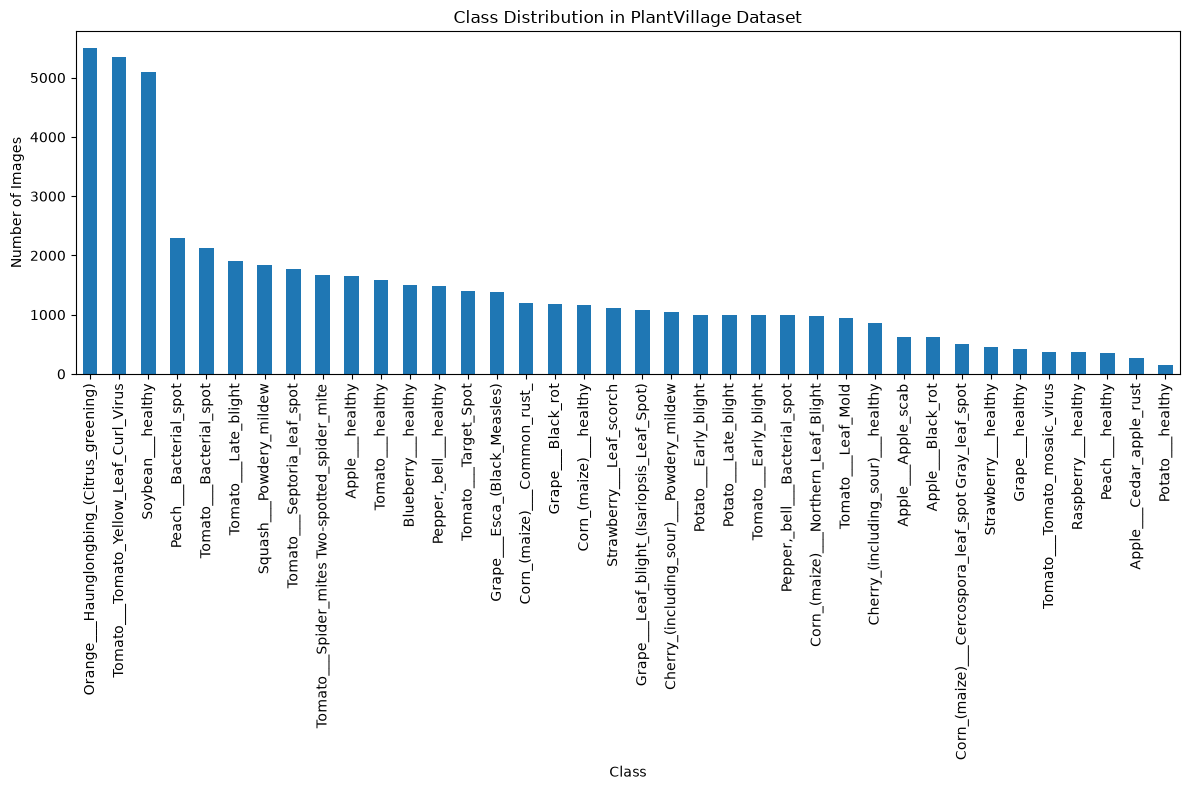

Class Distribution Summary:
Total Classes: 38
Min images in a class: 152 (Potato___healthy)
Max images in a class: 5507 (Orange___Haunglongbing_(Citrus_greening))
Mean images per class: 1429.08
Imbalance ratio (Max/Min): 36.23


In [4]:
df = pd.DataFrame(all_images, columns=['class', 'filename', 'filepath'])
class_counts = df['class'].value_counts()

plt.figure(figsize=(12, 8))
class_counts.plot(kind='bar')
plt.title("Class Distribution in PlantVillage Dataset")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print("Class Distribution Summary:")
print(f"Total Classes: {len(class_counts)}")
print(f"Min images in a class: {class_counts.min()} ({class_counts.idxmin()})")
print(f"Max images in a class: {class_counts.max()} ({class_counts.idxmax()})")
print(f"Mean images per class: {class_counts.mean():.2f}")
print(f"Imbalance ratio (Max/Min): {class_counts.max() / class_counts.min():.2f}")

## 4. Duplicate-Group-Aware Stratified Split (70/15/15)
To prevent data leakage, we identified exact (SHA-256) and near (pHash) duplicates. We treat each duplicate group as an indivisible unit, ensuring that all copies of the same image are assigned to the same split (train, validation, or test). The split targets 70/15/15 proportions per class using a fixed random seed.

In [5]:
import random

# Combine exact and near duplicates into connected components (groups)
# A simple disjoint-set / union-find can do this, or just grouping
group_map = {}
group_counter = 0

for h, paths in exact_hashes.items():
    if len(paths) > 1:
        group_id = group_counter
        group_counter += 1
        for p in paths:
            group_map[p] = group_id

for h, paths in phashes.items():
    if len(paths) > 1:
        # Check if any path is already in a group
        existing_groups = set(group_map[p] for p in paths if p in group_map)
        if not existing_groups:
            group_id = group_counter
            group_counter += 1
        else:
            group_id = list(existing_groups)[0]
            # Merge groups if there are multiple (not strictly needed since we only have 43 groups, but safe)
            for g in list(existing_groups)[1:]:
                for p, gid in group_map.items():
                    if gid == g:
                        group_map[p] = group_id
                        
        for p in paths:
            group_map[p] = group_id

# Assign unique group IDs to all other images
for cls, img_name, filepath in all_images:
    if filepath not in group_map:
        group_map[filepath] = group_counter
        group_counter += 1

df['group'] = df['filepath'].map(group_map)

# Group Stratified Split
train_records, val_records, test_records = [], [], []

random.seed(42)

for cls in df['class'].unique():
    cls_df = df[df['class'] == cls]
    # Group by group_id
    groups = [group for _, group in cls_df.groupby('group')]
    random.shuffle(groups)
    
    target_train = int(len(cls_df) * 0.70)
    target_val = int(len(cls_df) * 0.15)
    
    cur_train, cur_val = 0, 0
    for g in groups:
        g_len = len(g)
        # Assign to the bin that most needs it
        if cur_train + g_len <= target_train or (cur_train / target_train if target_train else 1) < (cur_val / target_val if target_val else 1):
             train_records.append(g)
             cur_train += g_len
        elif cur_val + g_len <= target_val or (cur_val / target_val if target_val else 1) < 1:
             val_records.append(g)
             cur_val += g_len
        else:
             test_records.append(g)

train_df = pd.concat(train_records).drop(columns=['group'])
val_df = pd.concat(val_records).drop(columns=['group'])
test_df = pd.concat(test_records).drop(columns=['group'])

print(f"Train set: {len(train_df)} images ({len(train_df)/len(df):.1%})")
print(f"Validation set: {len(val_df)} images ({len(val_df)/len(df):.1%})")
print(f"Test set: {len(test_df)} images ({len(test_df)/len(df):.1%})")

# Verify Leakage
train_groups = set(train_df['filepath'].map(group_map))
val_groups = set(val_df['filepath'].map(group_map))
test_groups = set(test_df['filepath'].map(group_map))

leakage = train_groups.intersection(val_groups) | train_groups.intersection(test_groups) | val_groups.intersection(test_groups)
if len(leakage) > 0:
    print(f"WARNING: Data leakage detected! {len(leakage)} groups cross boundaries.")
else:
    print("Verification Passed: No duplicate groups cross train/val/test boundaries.")

# Save splits
train_df.to_csv(os.path.join(SPLIT_DIR, 'train.csv'), index=False)
val_df.to_csv(os.path.join(SPLIT_DIR, 'val.csv'), index=False)
test_df.to_csv(os.path.join(SPLIT_DIR, 'test.csv'), index=False)
print("Split metadata saved successfully in `data/splits/`.")

Train set: 37997 images (70.0%)
Validation set: 8129 images (15.0%)
Test set: 8179 images (15.1%)
Verification Passed: No duplicate groups cross train/val/test boundaries.


Split metadata saved successfully in `data/splits/`.
